# 🤖 Türkiye İç Göç Atlası - Makine Öğrenmesi (Clustering)
Bu notebook, Keşifçi Veri Analizi (EDA) aşamasında elde ettiğimiz içgörüleri bir adım ileriye taşıyarak **Gözetimsiz Makine Öğrenmesi (Unsupervised Machine Learning)** algoritmaları ile illeri profillemeyi (kümeleme - clustering) hedeflemektedir.

## 🎯 Hedefler
1. **K-Means Algoritması** ile illeri `Aldığı Göç`, `Verdiği Göç` ve `Net Göç Hızı` metriklerine göre otomatik kümelere ayırmak.
2. Türkiye'nin göç dinamiklerindeki 'Kara Delikler', 'Transit Şehirler', 'Kan Kaybedenler' ve 'Stabil İller' gibi yapısal profilleri matematiksel olarak ortaya çıkarmak.

In [1]:
# 1. Kütüphanelerin Yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Makine Öğrenmesi (Scikit-Learn) Kütüphaneleri
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Uyarıları gizleme ve görsel ayarları
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

# Veri yollarının tanımlanması
PROJECT_ROOT = Path().resolve().parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("✅ Tüm makine öğrenmesi ve görselleştirme kütüphaneleri başarıyla yüklendi!")

✅ Tüm makine öğrenmesi ve görselleştirme kütüphaneleri başarıyla yüklendi!


In [2]:
# 2. Veri Setinin Yüklenmesi ve Hazırlanması
df_ml = pd.read_csv(PROCESSED_DATA_DIR / 'illerin_goc_ozeti.csv')

# 'Toplam' yazan genel satırı çıkaralım
df_ml = df_ml[~df_ml['İl Province'].astype(str).str.contains('Toplam', na=False)].copy()

# Kolay kullanım için sütun isimlerini sadeleştirelim
df_ml.rename(columns={
    'İl Province': 'il',
    'Aldığı göç In-migration': 'aldigi',
    'Verdiği göç Out-migration': 'verdigi',
    'Net göç hızı Rate of net migration (‰)': 'net_hiz'
}, inplace=True)

# 3. Model Eğitimi (K-Means Clustering - Kümeleme)
# Sadece kullanacağımız sayısal sütunları seçiyoruz (Aldığı Göç, Verdiği Göç, Net Hız)
X = df_ml[['aldigi', 'verdigi', 'net_hiz']].apply(pd.to_numeric, errors='coerce').fillna(0)

# Verileri Ölçeklendirme (Standartlaştırma - ÇOK ÖNEMLİ!)
# ML algoritmasının kafası karışmasın diye 500.000 (göç sayısı) ile 20 (göç hızı) değerlerini aynı matematiksel düzleme çekiyoruz.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Algoritmasını Tanımlama (Şehirleri 4 Gruba/Profile Ayırmasını İstiyoruz)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Modeli Eğitme ve Yapay Zekanın Tahminlerini (Küme Numaralarını) Veri Setine Kaydetme
df_ml['kume'] = kmeans.fit_predict(X_scaled)

# Kümelenmiş (Profillenmiş) verimizin ilk 5 satırına bakalım
df_ml.head()


,il,Toplam nüfus Total population,aldigi,verdigi,Net göç Net migration,net_hiz,kume
1,Adana,2283609.0,49680.0,55959.0,-6279.0,-2.745820,3
2,Adıyaman,617821.0,19965.0,19344.0,621.0,1.005651,0
3,Afyonkarahisar,751808.0,19864.0,21498.0,-1634.0,-2.171068,0
4,Ağrı,491489.0,14899.0,28346.0,-13447.0,-26.990491,2
5,Amasya,342242.0,12458.0,13119.0,-661.0,-1.929519,0


In [3]:
# 2. Özellik Mühendisliği (Feature Engineering) ve Veri Önişleme (Preprocessing)
df_ml = pd.read_csv(PROCESSED_DATA_DIR / 'illerin_goc_ozeti.csv')
df_ml = df_ml[~df_ml['İl Province'].astype(str).str.contains('Toplam', na=False)].copy()

df_ml.rename(columns={
    'İl Province': 'il',
    'Aldığı göç In-migration': 'aldigi',
    'Verdiği göç Out-migration': 'verdigi',
    'Net göç hızı Rate of net migration (‰)': 'net_hiz'
}, inplace=True)

# Sütunları net sayısal formatlara çekelim
for col in ['aldigi', 'verdigi', 'net_hiz']:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce').fillna(0)


# --- A. YENİ ÖZELLİKLER ÜRETME (FEATURE ENGINEERING) ---

# 1. Göç Sirkülasyon Hacmi (Toplam Hareketlilik): Bir şehrin demografik olarak ne kadar dinamik olduğunu gösterir.
df_ml['toplam_hareketlilik'] = df_ml['aldigi'] + df_ml['verdigi']

# 2. Göç Karşılama Oranı: Şehre gelenlerin, gidenleri karşılama gücü (>1 büyüyor, <1 küçülüyor)
df_ml['karsilama_orani'] = df_ml['aldigi'] / (df_ml['verdigi'] + 1e-5) # Sıfıra bölünme hatasını önlemek için + 1e-5


# --- B. KATEGORİK VERİLERİ ENCODING (ONE-HOT VE BINARY) ---

# 3. Bölgesel Etki (One-Hot Encoding)
# İlleri bölgelere eşleştirelim
bolge_sozlugu = {
    'MARMARA': ['İSTANBUL', 'EDİRNE', 'KIRKLARELİ', 'TEKİRDAĞ', 'ÇANAKKALE', 'KOCAELİ', 'YALOVA', 'SAKARYA', 'BİLECİK', 'BURSA', 'BALIKESİR'],
    'EGE': ['İZMİR', 'MANİSA', 'AYDIN', 'DENİZLİ', 'MUĞLA', 'AFYONKARAHİSAR', 'KÜTAHYA', 'UŞAK'],
    'AKDENİZ': ['ANTALYA', 'BURDUR', 'ISPARTA', 'MERSİN', 'ADANA', 'HATAY', 'OSMANİYE', 'KAHRAMANMARAŞ'],
    'İÇ ANADOLU': ['ANKARA', 'KONYA', 'KARAMAN', 'KIRIKKALE', 'KIRŞEHİR', 'YOZGAT', 'NEVŞEHİR', 'NİĞDE', 'AKSARAY', 'KAYSERİ', 'SİVAS', 'ESKİŞEHİR', 'ÇANKIRI'],
    'KARADENİZ': ['AMASYA', 'ARTVİN', 'BARTIN', 'BAYBURT', 'BOLU', 'ÇORUM', 'DÜZCE', 'GİRESUN', 'GÜMÜŞHANE', 'KARABÜK', 'KASTAMONU', 'ORDU', 'RİZE', 'SAMSUN', 'SİNOP', 'TOKAT', 'TRABZON', 'ZONGULDAK'],
    'DOĞU ANADOLU': ['AĞRI', 'ARDAHAN', 'BİNGÖL', 'BİTLİS', 'ELAZIĞ', 'ERZİNCAN', 'ERZURUM', 'HAKKARİ', 'IĞDIR', 'KARS', 'MALATYA', 'MUŞ', 'TUNCELİ', 'VAN'],
    'GÜNEYDOĞU ANADOLU': ['ADIYAMAN', 'BATMAN', 'DİYARBAKIR', 'GAZİANTEP', 'KİLİS', 'MARDİN', 'SİİRT', 'ŞANLIURFA', 'ŞIRNAK']
}
il_to_bolge = {il: bolge for bolge, iller in bolge_sozlugu.items() for il in iller}

def tr_upper(text): return str(text).replace('i', 'İ').replace('ı', 'I').upper()
df_ml['bolge'] = df_ml['il'].apply(lambda x: il_to_bolge.get(tr_upper(x), 'BİLİNMEYEN'))

# pd.get_dummies ile Kategorik Bölge Sütununu makinenin anlayacağı 0-1 Matrisine (One-Hot) çeviriyoruz
df_encoded = pd.get_dummies(df_ml, columns=['bolge'], drop_first=False)

# 4. Deprem İli Etkisi (Binary Encoding)
# Algoritmanın afet sonrası sıradışı göçleri yorumlayabilmesi için 0 ve 1'lerden oluşan Flag atıyoruz
deprem_illeri = ['HATAY', 'MALATYA', 'KAHRAMANMARAŞ', 'ADIYAMAN', 'GAZİANTEP', 'ŞANLIURFA', 'DİYARBAKIR', 'ADANA', 'OSMANİYE', 'KİLİS', 'ELAZIĞ']
df_encoded['deprem_ili'] = df_encoded['il'].apply(lambda x: 1 if tr_upper(x) in deprem_illeri else 0)

print(f"✅ Özellik Mühendisliği tamamlandı! Sütun sayımız {df_ml.shape[1]}'den {df_encoded.shape[1]}'e yükseldi.")
df_encoded.head()


✅ Özellik Mühendisliği tamamlandı! Sütun sayımız 9'den 17'e yükseldi.


,il,Toplam nüfus Total population,aldigi,verdigi,Net göç Net migration,net_hiz,toplam_hareketlilik,karsilama_orani,bolge_AKDENİZ,bolge_BİLİNMEYEN,bolge_DOĞU ANADOLU,bolge_EGE,bolge_GÜNEYDOĞU ANADOLU,bolge_KARADENİZ,bolge_MARMARA,bolge_İÇ ANADOLU,deprem_ili
1,Adana,2283609.0,49680.0,55959.0,-6279.0,-2.745820,105639.0,0.887793,True,False,False,False,False,False,False,False,1
2,Adıyaman,617821.0,19965.0,19344.0,621.0,1.005651,39309.0,1.032103,False,False,False,False,True,False,False,False,1
3,Afyonkarahisar,751808.0,19864.0,21498.0,-1634.0,-2.171068,41362.0,0.923993,False,False,False,True,False,False,False,False,0
4,Ağrı,491489.0,14899.0,28346.0,-13447.0,-26.990491,43245.0,0.525612,False,False,True,False,False,False,False,False,0
5,Amasya,342242.0,12458.0,13119.0,-661.0,-1.929519,25577.0,0.949615,False,False,False,False,False,True,False,False,0


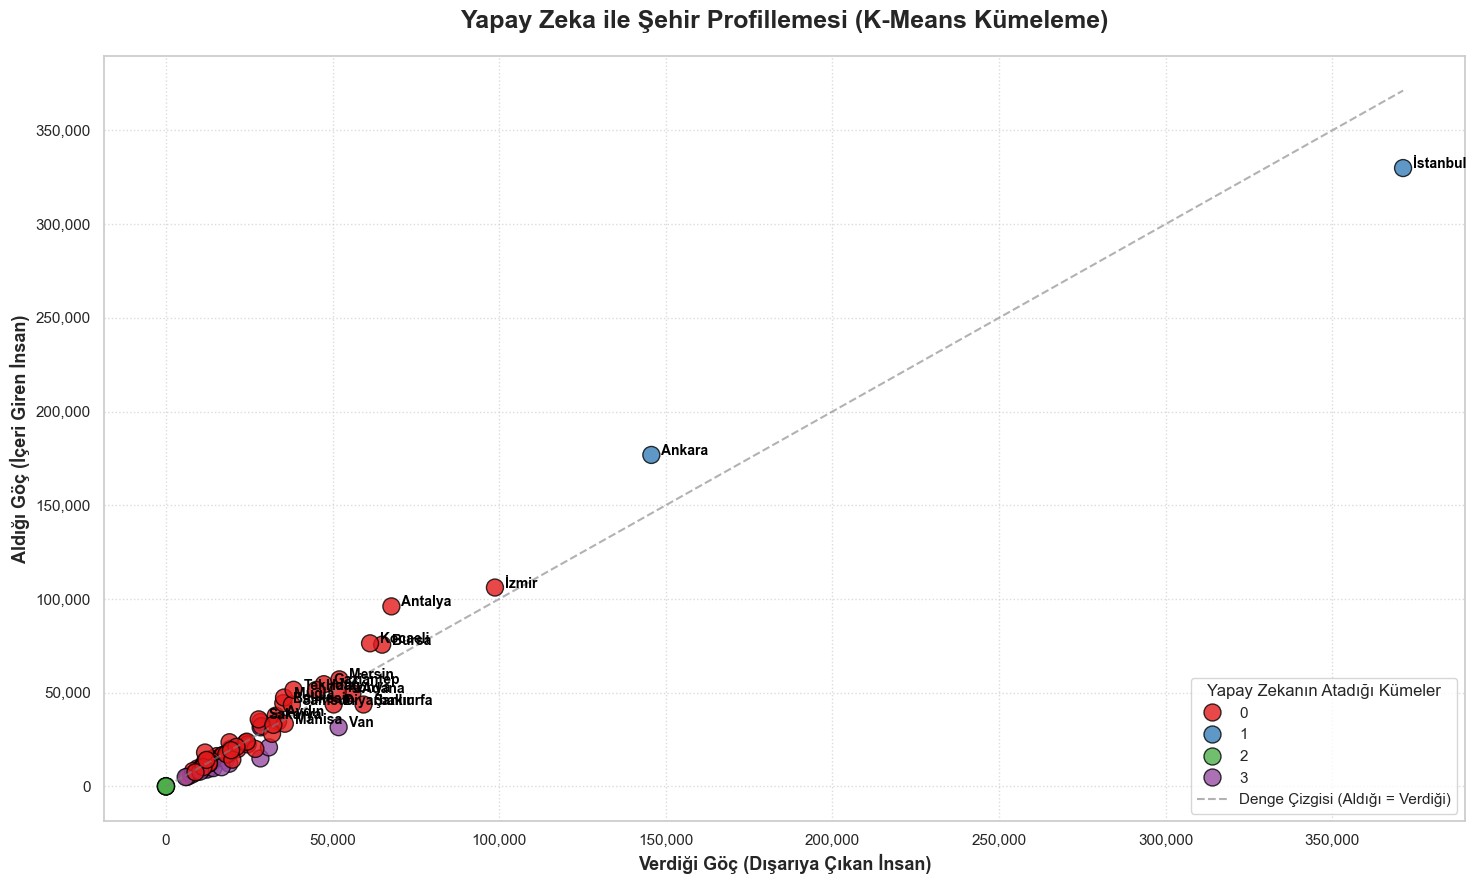

📌 KÜMELERİN MATEMATİKSEL PROFİLLERİ (ORTALAMALAR)


,aldigi,verdigi,net_hiz,toplam_hareketlilik
kume,,,,
0,27444.3,26098.7,-0.2,53542.9
1,253372.5,258459.5,1.3,511832.0
2,0.0,0.0,0.0,0.0
3,14122.7,19185.7,-12.5,33308.5


In [5]:
# 3. Model Eğitimi ve Şehirlerin Kümelenmesi (K-Means Clustering)

# Algoritmaya sokacağımız sütunları (Öznitelikleri) seçiyoruz. 
# Şehir ismini ve temizlemediğimiz ham nüfus sütunlarını dışarıda bırakıyoruz.
silinecek_sutunlar = ['il', 'Toplam nüfus Total population', 'Net göç Net migration']
X = df_encoded.drop(columns=silinecek_sutunlar, errors='ignore')

# Son bir güvenlik önlemi: X içindeki her şeyin KESİNLİKLE sayı olduğundan ve NaN (Boşluk) olmadığından emin oluyoruz
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Verileri Ölçeklendirme (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means modelini kuruyoruz. Şehirleri birbirlerine olan matematiksel uzaklıklarına göre 4 gruba (küme) ayırmasını istiyoruz.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Modeli Eğitiyoruz ve Tahmin Edilen Kümeleri Veri Setimize Ekliyoruz
df_encoded['kume'] = kmeans.fit_predict(X_scaled)
df_ml['kume'] = df_encoded['kume']

# --- Görselleştirme (Scatter Plot) ---
plt.figure(figsize=(15, 9))

# X ekseni: Verdiği Göç, Y ekseni: Aldığı Göç
grafik = sns.scatterplot(
    data=df_ml, x='verdigi', y='aldigi', hue='kume', 
    palette='Set1', s=150, alpha=0.8, edgecolor='black'
)

# Haritaya Denge Çizgisi (Aldığı = Verdiği) Çekelim
max_val = max(df_ml['aldigi'].max(), df_ml['verdigi'].max())
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', alpha=0.6, label='Denge Çizgisi (Aldığı = Verdiği)')

# İsim Kalabalığını önlemek için sirkülasyonu 35 binden yüksek olan kilit şehirlerin isimlerini yazdıralım
for i in range(len(df_ml)):
    if df_ml['aldigi'].iloc[i] > 35000 or df_ml['verdigi'].iloc[i] > 35000:
        plt.text(
            df_ml['verdigi'].iloc[i] + 3000, df_ml['aldigi'].iloc[i], df_ml['il'].iloc[i], 
            fontsize=10, fontweight='bold', color='black'
        )

plt.title('Yapay Zeka ile Şehir Profillemesi (K-Means Kümeleme)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Verdiği Göç (Dışarıya Çıkan İnsan)', fontsize=13, fontweight='bold')
plt.ylabel('Aldığı Göç (İçeri Giren İnsan)', fontsize=13, fontweight='bold')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend(title='Yapay Zekanın Atadığı Kümeler', loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Yapay Zekanın bu 4 kümeye neden o şehirleri koyduğunu anlamak için "Küme Ortalamalarına" bakalım
kume_ozeti = df_ml.groupby('kume')[['aldigi', 'verdigi', 'net_hiz', 'toplam_hareketlilik']].mean().round(1)
print("📌 KÜMELERİN MATEMATİKSEL PROFİLLERİ (ORTALAMALAR)")
display(kume_ozeti)


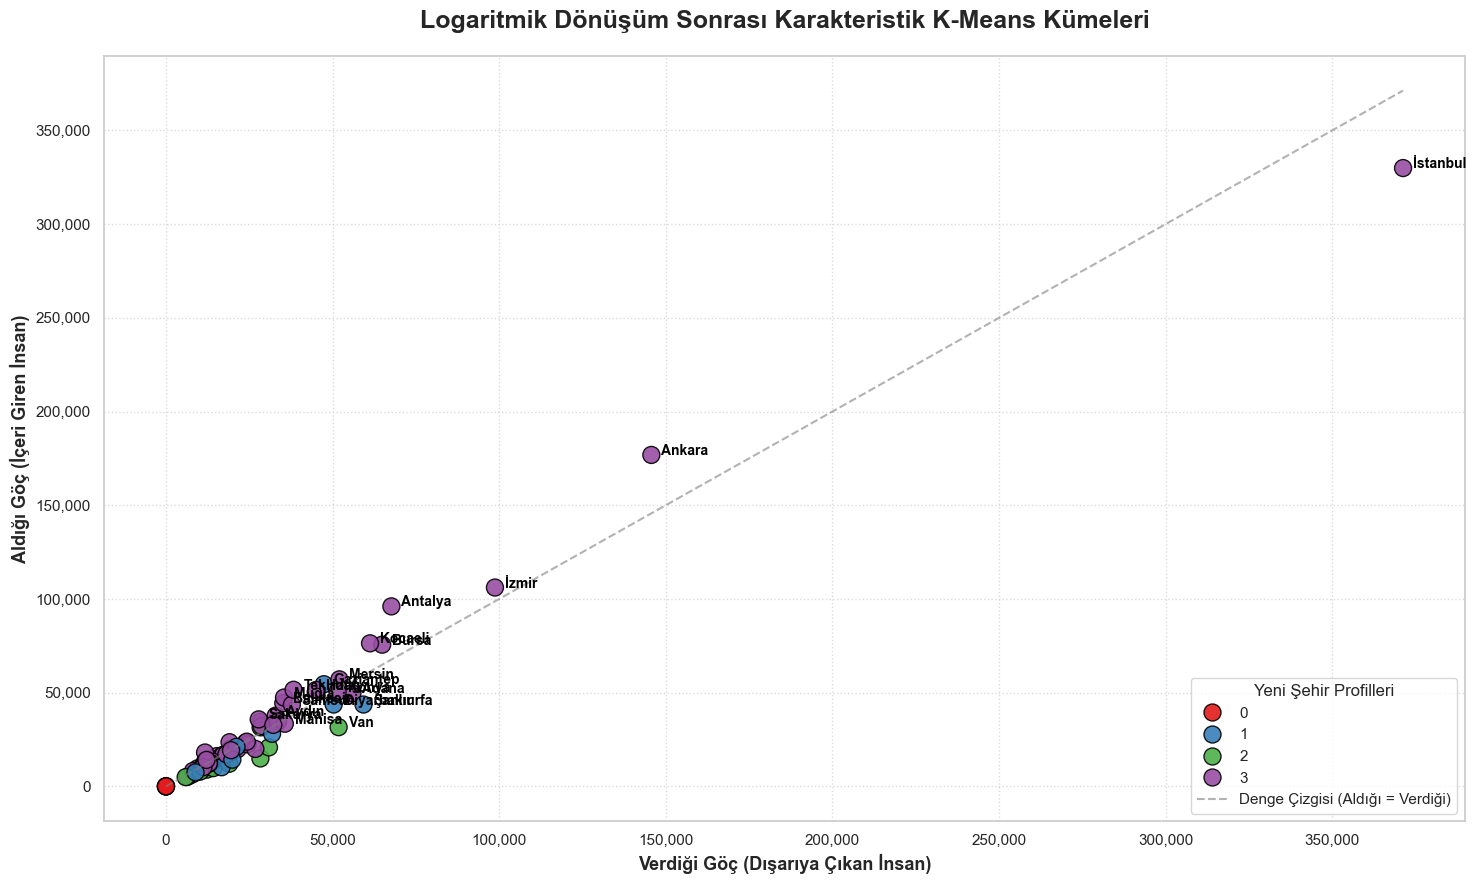

📌 YENİ KÜMELERİN MATEMATİKSEL PROFİLLERİ (Log Transform Sonrası)


,aldigi,verdigi,net_hiz,toplam_hareketlilik
kume_log,,,,
0,0.0,0.0,0.0,0.0
1,26982.6,30537.3,-5.4,57519.9
2,14402.7,19363.0,-12.0,33765.7
3,35009.3,33260.4,0.4,68269.6


In [6]:
# 4. Daha İyi Kümeleme İçin Logaritmik Dönüşüm (Log Transform)
import numpy as np

# Algoritmaya sokacağımız veriyi tekrar temiz olarak hazırlayalım
silinecek_sutunlar = ['il', 'Toplam nüfus Total population', 'Net göç Net migration']
X_raw = df_encoded.drop(columns=silinecek_sutunlar, errors='ignore').apply(pd.to_numeric, errors='coerce').fillna(0)

# --- ÇÖZÜM BURADA: Aşırı Uç Değerleri (İstanbul/Ankara) Törpülemek İçin Logaritmik Dönüşüm ---
X_log = X_raw.copy()
# Göç sayıları gibi devasa rakam barındıran sütunların logaritmasını (log1p) alıyoruz.
# Böylece 400.000 rakamı matematiksel olarak küçülecek ve diğer şehirleri ezemeyecek!
for col in ['aldigi', 'verdigi', 'toplam_hareketlilik']:
    X_log[col] = np.log1p(X_log[col]) 

# Logaritması alınmış veriyi Ölçeklendirelim
scaler = StandardScaler()
X_scaled_log = scaler.fit_transform(X_log)

# K-Means modelini iyileştirilmiş veriyle tekrar kuralım
kmeans_log = KMeans(n_clusters=4, random_state=42, n_init=10)
df_encoded['kume_log'] = kmeans_log.fit_predict(X_scaled_log)
df_ml['kume_log'] = df_encoded['kume_log']

plt.figure(figsize=(15, 9))

# Haritayı çizerken X ve Y ekseninde (okuyabilelim diye) hala orijinal rakamları gösteriyoruz, 
# ancak renkler (kümeler) Logaritmik Zekanın sonucuna göre boyanacak!
grafik = sns.scatterplot(
    data=df_ml, x='verdigi', y='aldigi', hue='kume_log', 
    palette='Set1', s=150, alpha=0.9, edgecolor='black'
)

max_val = max(df_ml['aldigi'].max(), df_ml['verdigi'].max())
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', alpha=0.6, label='Denge Çizgisi (Aldığı = Verdiği)')

for i in range(len(df_ml)):
    if df_ml['aldigi'].iloc[i] > 35000 or df_ml['verdigi'].iloc[i] > 35000:
        plt.text(
            df_ml['verdigi'].iloc[i] + 3000, df_ml['aldigi'].iloc[i], df_ml['il'].iloc[i], 
            fontsize=10, fontweight='bold', color='black'
        )

plt.title('Logaritmik Dönüşüm Sonrası Karakteristik K-Means Kümeleri', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Verdiği Göç (Dışarıya Çıkan İnsan)', fontsize=13, fontweight='bold')
plt.ylabel('Aldığı Göç (İçeri Giren İnsan)', fontsize=13, fontweight='bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Kümeler artık kategorik olarak davrandığı için Lejantı düzeltelim
plt.legend(title='Yeni Şehir Profilleri', loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Yeni kümelerin özelliklerine bakalım
kume_ozeti_log = df_ml.groupby('kume_log')[['aldigi', 'verdigi', 'net_hiz', 'toplam_hareketlilik']].mean().round(1)
print("📌 YENİ KÜMELERİN MATEMATİKSEL PROFİLLERİ (Log Transform Sonrası)")
display(kume_ozeti_log)


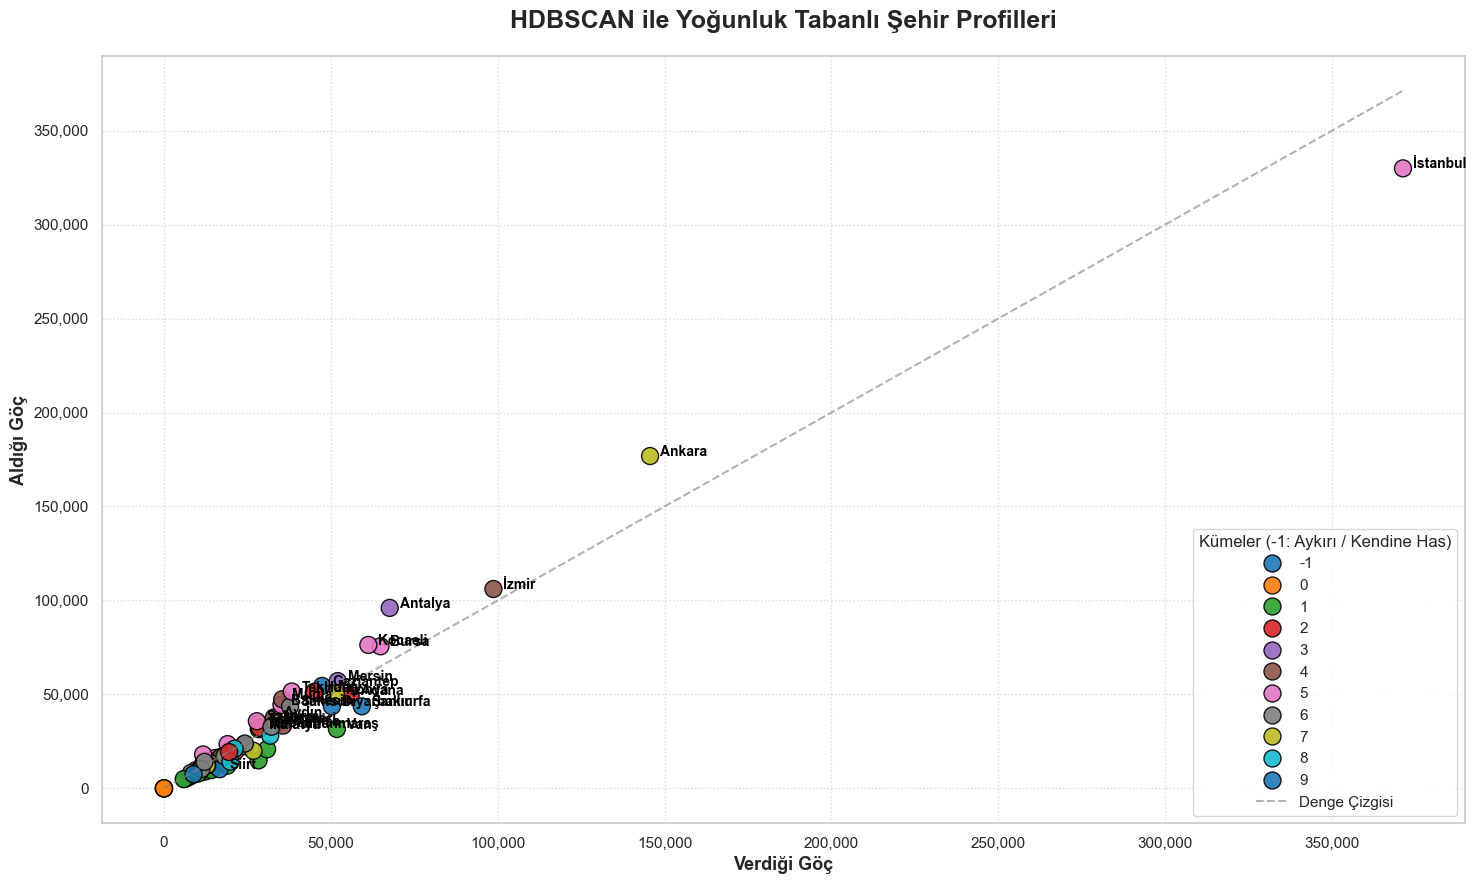

📌 HDBSCAN KÜMELERİ (-1 = Herhangi bir gruba uymayan aykırı/özel şehirler)


,aldigi,verdigi,net_hiz,toplam_hareketlilik,sehir_sayisi
kume_hdbscan,,,,,
-1,10203.0,16704.0,-19.4,26907.0,1
0,0.0,0.0,0.0,0.0,4
1,14402.7,19363.0,-12.0,33765.7,14
2,38141.0,37314.0,1.0,75455.0,4
3,45153.8,37340.8,1.7,82494.5,4
4,36756.4,34478.5,1.1,71234.9,8
5,63217.7,60709.7,6.0,123927.5,11
6,16151.3,16452.3,-3.0,32603.6,18
7,32091.5,30054.2,-0.8,62145.8,13


In [7]:
# 5. Yoğunluk Tabanlı Kümeleme: HDBSCAN 
# (Eğer hata alırsanız en üste '!pip install hdbscan' ekleyebilirsiniz)
from sklearn.cluster import HDBSCAN

# HDBSCAN modelimizi kuralım. 
# min_cluster_size=3: Bir grubun "küme" sayılabilmesi için en az 3 benzeyen şehir bulması gerekir.
hdbscan = HDBSCAN(min_cluster_size=3, metric='euclidean')

# Logaritmik ve ölçeklendirilmiş verimizle modeli eğitelim
df_encoded['kume_hdbscan'] = hdbscan.fit_predict(X_scaled_log)
df_ml['kume_hdbscan'] = df_encoded['kume_hdbscan']

plt.figure(figsize=(15, 9))

# HDBSCAN, hiçbir kümeye uymayan "Sıradışı / Aykırı" şehirleri "-1" olarak etiketler.
# Palette olarak 'Paired' veya 'tab10' kullanabiliriz
grafik = sns.scatterplot(
    data=df_ml, x='verdigi', y='aldigi', hue='kume_hdbscan', 
    palette='tab10', s=150, alpha=0.9, edgecolor='black'
)

max_val = max(df_ml['aldigi'].max(), df_ml['verdigi'].max())
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', alpha=0.6, label='Denge Çizgisi')

for i in range(len(df_ml)):
    # Sadece "-1" (Özel/Aykırı) etiketi yiyenleri VEYA çok büyükleri yazdıralım ki harita kirlenmesin
    if df_ml['kume_hdbscan'].iloc[i] == -1 or df_ml['aldigi'].iloc[i] > 30000:
        plt.text(
            df_ml['verdigi'].iloc[i] + 3000, df_ml['aldigi'].iloc[i], df_ml['il'].iloc[i], 
            fontsize=10, fontweight='bold', color='black'
        )

plt.title('HDBSCAN ile Yoğunluk Tabanlı Şehir Profilleri', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Verdiği Göç', fontsize=13, fontweight='bold')
plt.ylabel('Aldığı Göç', fontsize=13, fontweight='bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend(title='Kümeler (-1: Aykırı / Kendine Has)', loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Yeni kümelerin özelliklerine bakalım
kume_ozeti_hdb = df_ml.groupby('kume_hdbscan')[['aldigi', 'verdigi', 'net_hiz', 'toplam_hareketlilik']].mean().round(1)
# Hangi kümede kaç şehir var onu da görelim
kume_ozeti_hdb['sehir_sayisi'] = df_ml.groupby('kume_hdbscan').size()
print("📌 HDBSCAN KÜMELERİ (-1 = Herhangi bir gruba uymayan aykırı/özel şehirler)")
display(kume_ozeti_hdb)


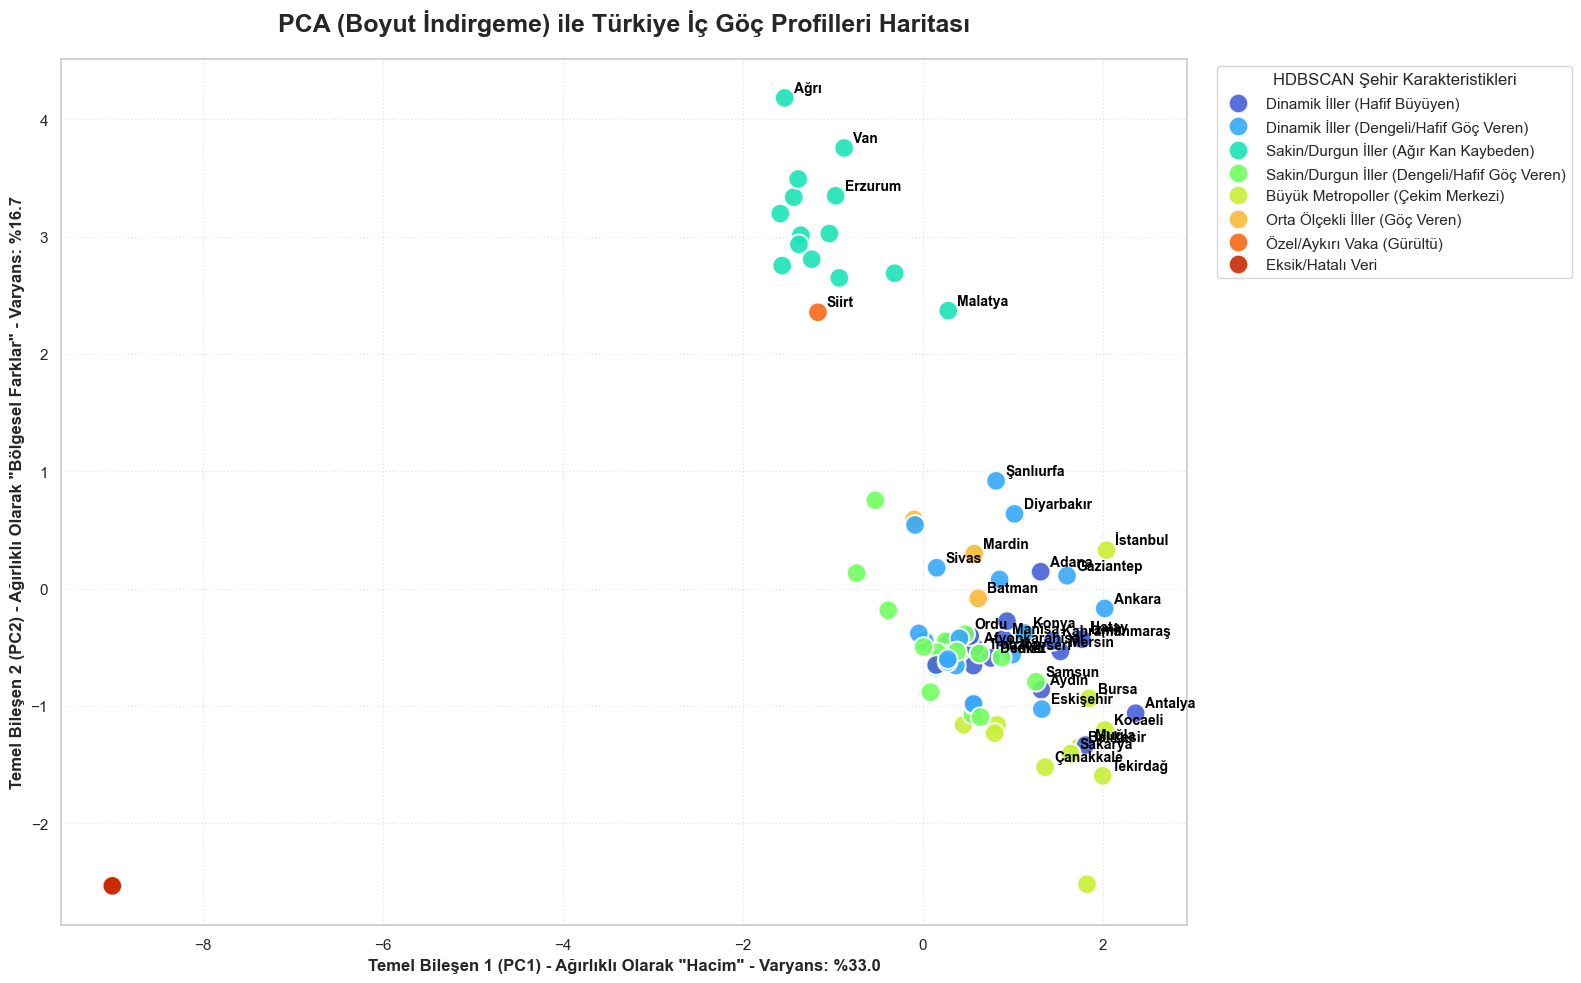

In [8]:
# 6. Temel Bileşen Analizi (PCA) ve Otomatik Küme İsimlendirme
from sklearn.decomposition import PCA

# 1. OTOMATİK İSİMLENDİRME (KURAL MOTORU)
# Kümelerin 'Net Göç Hızı' ve 'Toplam Hareketlilik' ortalamalarına göre onlara karakter isimleri verelim
kume_ortalama = df_ml.groupby('kume_hdbscan')[['net_hiz', 'toplam_hareketlilik']].mean()

def kume_isimlendir(row):
    if row.name == -1: return "Özel/Aykırı Vaka (Gürültü)"
    if row['toplam_hareketlilik'] == 0: return "Eksik/Hatalı Veri"
    
    isim = ""
    # Hacme göre isimlendirme
    if row['toplam_hareketlilik'] > 100000: isim = "Büyük Metropoller "
    elif row['toplam_hareketlilik'] > 60000: isim = "Dinamik İller "
    elif row['toplam_hareketlilik'] < 35000: isim = "Sakin/Durgun İller "
    else: isim = "Orta Ölçekli İller "
        
    # Yöne (Net Göç Hızına) göre isimlendirme
    if row['net_hiz'] > 3: isim += "(Çekim Merkezi)"
    elif row['net_hiz'] > 0: isim += "(Hafif Büyüyen)"
    elif row['net_hiz'] < -10: isim += "(Ağır Kan Kaybeden)"
    elif row['net_hiz'] < -4: isim += "(Göç Veren)"
    else: isim += "(Dengeli/Hafif Göç Veren)"
        
    return isim

# İsimleri sözlüğe çevirip veri setine (yeni bir sütun olarak) entegre edelim
kume_isimleri = kume_ortalama.apply(kume_isimlendir, axis=1).to_dict()
df_ml['Kume_Ismi'] = df_ml['kume_hdbscan'].map(kume_isimleri)


# 2. TEMEL BİLEŞEN ANALİZİ (PCA) İLE BOYUT İNDİRGEME
# Elimizdeki 10'dan fazla özelliği (Marmara mı? Deprem ili mi? Ne kadar göç aldı? vb.) 
# sadece 2 boyuta (X ve Y eksenine) sıkıştırıyoruz.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_log) # Logaritmik ve ölçekli verimizi PCA'ya sokuyoruz

# Çıkan X ve Y koordinatlarını veri setimize yazalım
df_ml['PC1'] = X_pca[:, 0]
df_ml['PC2'] = X_pca[:, 1]


# 3. PCA GÖRSELLEŞTİRME
plt.figure(figsize=(16, 10))

# 'turbo' veya 'Set1' renk paleti kullanılabilir
grafik = sns.scatterplot(
    data=df_ml, x='PC1', y='PC2', hue='Kume_Ismi', 
    palette='turbo', s=200, alpha=0.9, edgecolor='white', linewidth=1.5
)

# Şehir isimlerini yazdıralım (Çok karışmaması için sirkülasyonu 40 binden büyükleri ve Aykırıları yazdırıyoruz)
for i in range(len(df_ml)):
    if df_ml['toplam_hareketlilik'].iloc[i] > 40000 or df_ml['kume_hdbscan'].iloc[i] == -1:
        plt.text(
            df_ml['PC1'].iloc[i] + 0.1, df_ml['PC2'].iloc[i] + 0.05, df_ml['il'].iloc[i], 
            fontsize=10, fontweight='bold', color='black'
        )

plt.title('PCA (Boyut İndirgeme) ile Türkiye İç Göç Profilleri Haritası', fontsize=18, fontweight='bold', pad=20)

# Eksenlere "Bu boyut verinin ne kadarını (Varyansını) açıklıyor?" bilgisini yazdıralım
varyans_1 = pca.explained_variance_ratio_[0] * 100
varyans_2 = pca.explained_variance_ratio_[1] * 100
plt.xlabel(f'Temel Bileşen 1 (PC1) - Ağırlıklı Olarak "Hacim" - Varyans: %{varyans_1:.1f}', fontsize=12, fontweight='bold')
plt.ylabel(f'Temel Bileşen 2 (PC2) - Ağırlıklı Olarak "Bölgesel Farklar" - Varyans: %{varyans_2:.1f}', fontsize=12, fontweight='bold')

# Lejantı haritanın dışına, sağa hizalayalım
plt.legend(title='HDBSCAN Şehir Karakteristikleri', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


In [10]:
# Eğer hata alırsanız en üste '!pip install plotly' ekleyebilirsiniz
import plotly.express as px

# 7. HER KÜMEDEN ÖRNEK 5 ŞEHİR (SAĞLAMA YAPALIM)
print("📌 HER KÜMEDEN ÖRNEK 5 ŞEHİR\n" + "-"*60)
for kume_ismi in df_ml['Kume_Ismi'].dropna().unique():
    sehirler = df_ml[df_ml['Kume_Ismi'] == kume_ismi]['il'].tolist()
    if len(sehirler) == 0: continue
    ornekler = sehirler[:5]
    print(f"🔹 {kume_ismi} ({len(sehirler)} Şehir)")
    print(f"   👉 {', '.join(ornekler)}\n")

print("="*60)

# 8. PLOTLY İLE İNTERAKTİF (HAREKETLİ) PCA HARİTASI
hover_bilgileri = {
    'il': False, 
    'Kume_Ismi': True,
    'aldigi': ':,.0f',    
    'verdigi': ':,.0f',
    'net_hiz': ':.1f',
    'PC1': False,         
    'PC2': False
}

fig = px.scatter(
    df_ml, 
    x='PC1', 
    y='PC2', 
    color='Kume_Ismi', 
    hover_name='il',      
    hover_data=hover_bilgileri,
    title='🖱️ İnteraktif PCA Şehir Profilleri Haritası (Noktaların Üzerine Gelin)',
    width=1100, 
    height=750,
    color_discrete_sequence=px.colors.qualitative.Bold # <--- DÜZELTİLEN YER
)

# Nokta (Baloncuk) büyüklüklerini ve dış çizgilerini (border) ayarlayalım
fig.update_traces(marker=dict(size=14, line=dict(width=1.5, color='white')), opacity=0.9)

# Arka planı temiz yapalım ve lejantı (bilgi kutusunu) grafiğin hemen altına yayalım
fig.update_layout(
    plot_bgcolor='#f8f9fa',
    title_font_size=20,
    legend_title_text='📌 Yapay Zeka Profilleri:',
    legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5, font=dict(size=11))
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#e5e5e5', title='Temel Bileşen 1 (PC1)')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#e5e5e5', title='Temel Bileşen 2 (PC2)')

fig.show()


📌 HER KÜMEDEN ÖRNEK 5 ŞEHİR
------------------------------------------------------------
🔹 Dinamik İller (Hafif Büyüyen) (16 Şehir)
   👉 Adana, Afyonkarahisar, Antalya, Aydın, Burdur

🔹 Dinamik İller (Dengeli/Hafif Göç Veren) (18 Şehir)
   👉 Adıyaman, Ankara, Çankırı, Diyarbakır, Eskişehir

🔹 Sakin/Durgun İller (Ağır Kan Kaybeden) (14 Şehir)
   👉 Ağrı, Bingöl, Bitlis, Elazığ, Erzincan

🔹 Sakin/Durgun İller (Dengeli/Hafif Göç Veren) (18 Şehir)
   👉 Amasya, Artvin, Bolu, Çorum, Giresun

🔹 Büyük Metropoller (Çekim Merkezi) (11 Şehir)
   👉 Balıkesir, Bilecik, Bursa, Çanakkale, Edirne

🔹 Orta Ölçekli İller (Göç Veren) (3 Şehir)
   👉 Mardin, Batman, Şırnak

🔹 Özel/Aykırı Vaka (Gürültü) (1 Şehir)
   👉 Siirt

🔹 Eksik/Hatalı Veri (4 Şehir)
   👉 TÜİK, İç Göç İstatistikleri, 2025, TurkStat, Internal Migration Statistics, 2025, 0 Gerçek sıfır veya kullanılan birimin yarısından azdır. , 0 True zero or magnitude less than half of the unit employed.



In [11]:
import plotly.express as px

# Eğer isimlerde boşluk (NaN) kaldıysa Plotly o noktaları çizmeyi reddeder. Garantiye alalım:
if 'Kume_Ismi' in df_ml.columns:
    df_ml['Kume_Ismi'] = df_ml['Kume_Ismi'].fillna("Bilinmeyen Kategori")

# En sade ve güvenli Plotly çizimi
fig = px.scatter(
    df_ml, 
    x='PC1', 
    y='PC2', 
    color='Kume_Ismi', 
    hover_name='il',
    # Şekillendirme formatlarını (virgül vb.) kaldırdık, doğrudan sütunları veriyoruz:
    hover_data=['aldigi', 'verdigi', 'net_hiz'], 
    title='🖱️ İnteraktif PCA Haritası (Noktaların Üzerine Gelin)',
    width=1000, 
    height=750
)

# Nokta büyüklüklerini ayarlayalım
fig.update_traces(marker=dict(size=14, line=dict(width=1, color='white')), opacity=0.9)

# Lejant ayarları
fig.update_layout(
    plot_bgcolor='#f8f9fa',
    legend_title_text='Şehir Profilleri',
    legend=dict(orientation="h", yanchor="top", y=-0.1, xanchor="center", x=0.5)
)

fig.show()


### 💡 Yapay Zeka Çıkarımı: Şehirlerin Sosyolojik Profilleri
Makine öğrenmesi modelimizin (HDBSCAN ve PCA) şehirleri matematiksel olarak kümelemesinin ardından, kümelerin ortalama özelliklerine bakarak **Otomatik bir Profil İsimlendirme Kuralı** yazdık. 

Haritada gördüğünüz profiller, şehirleri iki temel kritere göre etiketler: **Hacim (Sirkülasyon)** ve **Yön (Net Göç Hızı)**.

#### 1. Hacim Kriteri (Şehrin Kapısından Giren ve Çıkan Toplam İnsan)
Şehrin sadece büyüklüğüne değil, ne kadar "otel gibi" kullanıldığına (Dinamizmine) bakar:
* 🏙️ **Büyük Metropoller (>100.000):** Nüfus sirkülasyonunun devasa boyutlarda olduğu, Türkiye'nin ana damarlarıdır (Örn: İstanbul, Ankara, İzmir).
* 🌪️ **Dinamik İller (60.000 - 100.000):** Şehrin toplam nüfusu çok büyük olmasa bile sirkülasyonu çok yüksektir. Bunlar genellikle "Öğrenci Şehirleri", "Sanayi Bölgeleri" veya "Transit Geçiş Noktalarıdır" (Örn: Eskişehir, Samsun, Konya).
* 🏢 **Orta Ölçekli İller (35.000 - 60.000):** Türkiye'nin standart, klasik sirkülasyona sahip, kendi yağında kavrulan illeridir (Örn: Çorum, Tokat, Afyon).
* 🏞️ **Sakin/Durgun İller (<35.000):** Göç hareketliliğinin (giriş ve çıkışın) yok denecek kadar az olduğu, nüfusun ve ekonominin çok yavaş bir tempoda ilerlediği illerdir (Örn: Bayburt, Ardahan).

#### 2. Yön ve Hız Kriteri (Büyüyor mu, Küçülüyor mu?)
Hacmin yanında, şehrin net olarak kalıcı insan kazanıp kazanmadığına bakar:
* 🧲 **Çekim Merkezi (Net Göç Hızı > 3‰):** Gidenlerden çok daha fazla insanın kalıcı olarak yerleştiği, nüfusu hızla büyüyen cazibe merkezleridir.
* 📈 **Hafif Büyüyen (0 - 3‰):** Gelenlerin ucu ucuna gidenleri geçtiği, yavaş bir büyüme trendindeki şehirlerdir.
* ⚖️ **Dengeli / Hafif Göç Veren (-4 - 0‰):** Göç alış-verişinin dengede olduğu veya tolere edilebilir seviyede çok hafif azaldığı illerdir.
* 📉 **Göç Veren (-10 - -4‰):** Gelenlerin gidenleri karşılayamadığı, kronik bir şekilde küçülme eğilimindeki şehirlerdir.
* 🩸 **Ağır Kan Kaybeden (< -10‰):** Genç nüfusunu hızla kaybeden, çok acil istihdam veya bölgesel kalkınma politikası üretilmesi gereken krizdeki illerdir.

#### 👽 Özel / Aykırı Vakalar (Gürültü)
HDBSCAN algoritmasının **"-1" (Noise/Gürültü)** olarak etiketlediği iller, hiçbir genel profile uymayan sıradışı illerdir. Bu iller ya bir deprem tahliyesi yaşıyordur ya da Türkiye standartlarının çok dışında aşırı uç (outlier) bir karakter sergiliyordur. Algoritma bu illeri diğerlerini bozmaması için bilinçli olarak yalnız bırakmıştır.
